In [8]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


x = np.linspace(-10, 10, 100)


In [9]:
def getplot(z):
    y = sigmoid(z)


    plt.plot(x, y)

    plt.xlabel("x")
    plt.ylabel("Probability")
    plt.title("Decision Boundary")
    plt.axvline(y = 0.5, linestyle="--")

    plt.grid(True)

    plt.show()

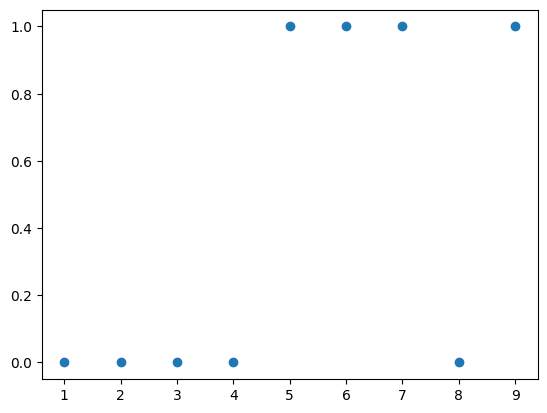

In [10]:
hours_studied = np.array([1,2,3,4,5,6,7,8,9])
result = np.array([0,0,0,0,1,1,1,0,1])

plt.scatter(hours_studied, result)
plt.show()

In [11]:
w = 2
b = -6

In [12]:
def predict_y(X, w, b):
    m = X.shape[0]
    y_probs = np.zeros(m)
    for i in range(m):
        y_probs[i] = sigmoid(w * X[i] + b)
    y_preds = np.where(y_probs >= 0.5, 1, 0)
    return y_probs, y_preds


In [13]:
y_probs, y_preds = predict_y(hours_studied, w,b)
y_probs, y_preds

(array([0.01798621, 0.11920292, 0.5       , 0.88079708, 0.98201379,
        0.99752738, 0.99966465, 0.9999546 , 0.99999386]),
 array([0, 0, 1, 1, 1, 1, 1, 1, 1]))

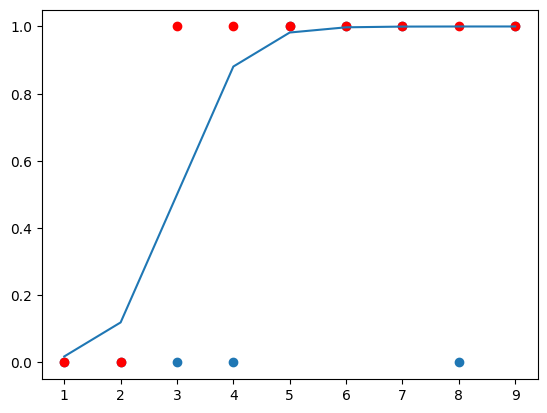

In [14]:
plt.scatter(hours_studied, result)
plt.scatter(hours_studied, y_preds, color="red")
plt.plot(hours_studied, y_probs)
plt.show()

In [15]:
def calc_cost(X, y, w, b, elipson=1e-5):
    m = X.shape[0]

    cost = 0.

    for i in range(m):
        z = w * X[i] + b
        f_wb = sigmoid(z)
        cost += -y[i] * np.log(f_wb + elipson) - \
            (1 - y[i]) * np.log(1 - f_wb + elipson)

    cost /= m
    return cost

In [16]:
def calc_gradient(X, y, w, b):
    m = X.shape[0]

    w_gradient = 0.
    b_gradient = 0.

    for i in range(m):
        z = w * X[i] + b
        y_pred = sigmoid(z)
        err = y_pred - y[i]
        w_gradient += err * X[i]
        b_gradient += err

    w_gradient /= m
    b_gradient /= m

    return w_gradient, b_gradient

In [17]:
print(
    f"initial w: {w}, initial b: {b}, initial_cost: {calc_cost(hours_studied, result, w, b)}\n")

w_gradient, b_gradient = calc_gradient(hours_studied, result, w, b)
print(f"w_gradient: {w_gradient}, b_gradient: {b_gradient}\n")

learning_rate = 0.01
w_new = w - learning_rate * w_gradient
b_new = b - learning_rate * b_gradient
print(
    f"final w: {w_new}, final b: {b_new}, final cost: {calc_gradient(hours_studied, result, w_new, b_new)}")

initial w: 2, initial b: -6, initial_cost: 1.4207693439799463

w_gradient: 1.463560849525921, b_gradient: 0.27746005385217715

final w: 1.9853643915047408, final b: -6.002774600538522, final cost: (np.float64(1.4550061265082141), np.float64(0.27484270601140703))


In [29]:
def gradient_descent(X, y, w, b, alpha=0.01, n_iters=2000, history_step=100):
    history = {}

    for iter in range(n_iters):
        dj_dw, dj_db = calc_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if iter % history_step == 0:
            cost = calc_cost(X, y, w, b)
            history[iter] = cost
            print(f"Iter\t{iter}\tCost\t{cost}")

    return history, w, b

In [30]:
history, w_new, b_new = gradient_descent(hours_studied, result, w, b)

Iter	0	Cost	1.6335948663162463
Iter	100	Cost	0.6393116822551037
Iter	200	Cost	0.6261081895868733
Iter	300	Cost	0.6141654271248052
Iter	400	Cost	0.6033490602475458
Iter	500	Cost	0.5935419601833974
Iter	600	Cost	0.58463887219456
Iter	700	Cost	0.576545585744707
Iter	800	Cost	0.5691780203351686
Iter	900	Cost	0.5624612885271587
Iter	1000	Cost	0.556328778024633
Iter	1100	Cost	0.5507212795522924
Iter	1200	Cost	0.5455861760646147
Iter	1300	Cost	0.5408767008494839
Iter	1400	Cost	0.5365512666341008
Iter	1500	Cost	0.5325728642346828
Iter	1600	Cost	0.5289085270991561
Iter	1700	Cost	0.5255288568689646
Iter	1800	Cost	0.5224076045261362
Iter	1900	Cost	0.5195213015698091


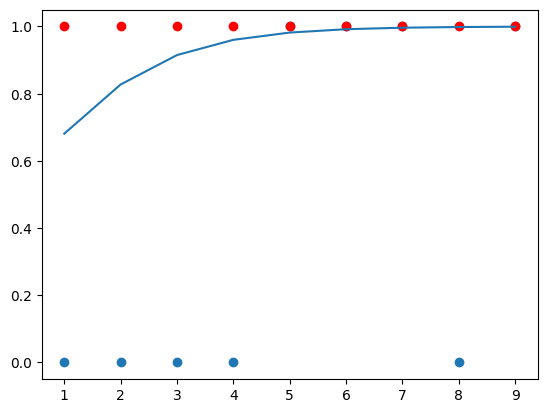

In [31]:
y_probs, y_preds = predict_y(hours_studied, w, b)
y_probs, y_preds
plt.scatter(hours_studied, result)
plt.scatter(hours_studied, y_preds, color="red")
plt.plot(hours_studied, y_probs)
plt.show()

In [32]:
def plot_history(history):
    plt.figure(figsize=(4, 3))
    plt.plot(history.keys(), history.values())
    plt.title("Cost over iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Cost")

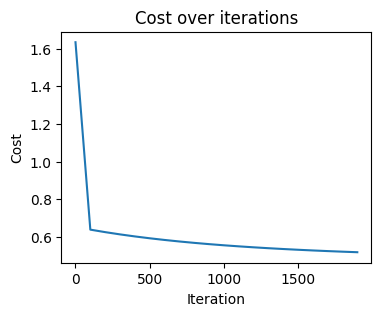

In [33]:
plot_history(history)